# TNG300：4冊の主要結果まとめ

**同程度の質量を持つ z≈8 ハローでも、最終ホスト質量には大きな幅がある。中心銀河の星質量・SFRより、10–15 cMpc程度の周辺環境が最終質量を絞る情報を持つ。**

前半は保存済み結果の要約表、後半は `../data/` のCSVから再計算するPDF比較です。PDF比較は NumPy・pandas・Matplotlib のみを使い、TNG本体やmerger treeの再読み込みは不要です。元解析を更新した際は、静的な要約表も更新してください。

| 共通条件・記号 | 定義 |
|---|---|
| シミュレーション | TNG300-1 |
| 初期時刻 → 最終時刻 | snapshot 8（z=8.012）→ snapshot 99（z=0） |
| 初期選択 | $10^{10.8}<M_8/M_\odot<10^{11.2}$、中心subhaloを持つFoFハロー |
| $M_0$ | z=0の子孫が属する**ホスト**の $M_{200c}$。子孫銀河自身の質量ではない |
| $\rho$ | 最終ホスト質量とのSpearman順位相関 |
| $W_{68}$ | $\log_{10}(M_0/M_\odot)$ の84−16パーセンタイル幅（dex） |
| cMpc | 共動Mpc |
| 周辺銀河・ハロー | 対象の中心銀河／対象FoF自身を除いて数える |

## 1. 初期ハローの行き先

元解析：[tng300_z8_descendant_mass.ipynb](tng300_z8_descendant_mass.ipynb)

| 指標 | 結果 |
|---|---:|
| 選択した初期ハロー | 3,099 |
| 最終ホスト情報を取得できた対象 | 3,099 / 3,099（100%） |
| $\log_{10}(M_0/M_\odot)$ の中央値 | 13.779 |
| $M_0$ の中央値 | $6.01\times10^{13}\,M_\odot$ |
| $\log_{10}(M_0/M_\odot)$ の16–84%範囲 | 13.012–14.386 |
| $W_{68}$ | 1.373 dex |
| $P(M_0>10^{13}M_\odot)$ | 84.25% |
| $P(M_0>10^{14}M_\odot)$ | 36.53% |
| $P(M_0>10^{15}M_\odot)$ | 2.36% |
| 重複を除いた最終FoFホスト | 1,761 |
| 複数の初期ハローが入る最終ホスト | 533 |
| 1つの最終ホストに入る初期ハローの最大数 | 33 |

**読み取り：** 初期質量を狭く揃えても、将来の所属ホストは広く分布する。上側確率の分母は3,099初期ハローであり、1,761独立ホストではない。取得率100%は、元の銀河が独立した天体として生き残る割合ではない。

## 2. 中心銀河の性質と5 cMpcの周辺銀河数

元解析：[tng300_descendant_with_galaxy_properties.ipynb](tng300_descendant_with_galaxy_properties.ipynb)

周辺銀河数は $R=5$ cMpc、$M_\star>10^8M_\odot$、`SubhaloFlag=1` の銀河で測定する。

| 条件・指標 | $\rho$ | 条件付き群内 $W_{68}$ の加重平均 [dex] | 基準に対する幅の縮小率 |
|---|---:|---:|---:|
| 初期ハロー質量範囲のみ（基準） | 約0.115 | 1.373 | — |
| 中心星質量で3群 | 0.040 | 1.386 | −0.9% |
| 中心SFRで3群 | 0.064 | 1.388 | −1.1% |
| 周辺銀河数で3群 | **0.475** | **1.192** | **13.2%** |
| 中心星質量 × 周辺銀河数で4群 | — | 1.245 | 9.4% |

基準は3,099対象、銀河特性の比較は星質量が正の3,098対象。4群は両指標の中央値による2×2分割。縮小率が負なら幅は拡大している。分割方法が違うため、3群と4群の幅だけで追加指標の有効性を比較しない。

| 補助的なRandom Forest評価 | RMSE [dex] | MAE [dex] |
|---|---:|---:|
| 初期ハロー質量のみ | 0.650 | 0.513 |
| 初期質量＋中心星質量＋SFR＋周辺銀河数 | **0.560** | **0.449** |

**読み取り：** 中心星質量・SFRで分けても最終ホスト質量の幅はほぼ縮まらない。5 cMpcの周辺銀河数はより強い情報を持つ。

## 3. 環境スケールと最終ホスト質量

元解析：[tng300_descendant_with_environment.ipynb](tng300_descendant_with_environment.ipynb)

測定半径は1, 2, 3, 5, 8, 10, 15, 20 cMpc。銀河は $M_\star>10^8M_\odot$、近隣ハローは $M_{200c}>10^{9.5}M_\odot$ を使う。

| 指標 | 最大相関の半径 [cMpc] | $\rho$ | 初期質量の線形傾向を除いた残差との $\rho$（同じ半径） |
|---|---:|---:|---:|
| 周辺銀河数 $N_{\rm gal}$ | 15 | 0.647 | 0.638 |
| 周辺星質量総和 | 10 | 0.615 | 0.603 |
| 周辺ハロー数 $N_{\rm halo}$ | **10** | **0.807** | **0.797** |
| 周辺ハロー質量総和 | 10 | 0.806 | 0.796 |
| 初期ハロー質量（比較基準） | — | 0.115 | — |

銀河数の相関は10 cMpcで0.6464、15 cMpcで0.6469とほぼ同じ。銀河環境は**10–15 cMpc付近の広いピーク**として読む。

| 15 cMpcの周辺銀河数による群 | 対象数 | $\log_{10}(M_0/M_\odot)$ 中央値 | $W_{68}$ [dex] |
|---|---:|---:|---:|
| 低銀河数 | 1,033 | 13.320 | 1.065 |
| 中銀河数 | 1,033 | 13.740 | 1.093 |
| 高銀河数 | 1,033 | **14.274** | **0.871** |
| 3群の加重平均幅 | 3,099 | — | **1.010** |

基準の1.373 dexから加重平均幅は約26.5%縮小する。群は順位で等人数に分けるため、境界では同じ銀河数の対象が別群へ入る場合がある。

| 補助的なRandom Forest評価 | RMSE [dex] | MAE [dex] |
|---|---:|---:|
| 初期ハロー質量のみ | 0.651 | 0.516 |
| 初期質量＋周辺銀河数 | 0.531 | 0.418 |
| 初期質量＋周辺銀河数＋周辺星質量総和 | **0.507** | **0.393** |

**読み取り：** 初期質量による傾向を除いても環境相関は強く残る。豊かな環境ほど最終質量が高く、条件付き分布も狭まる。

## 4. 環境測定の頑健性：質量閾値

元解析：[tng300_environment_robustness.ipynb](tng300_environment_robustness.ipynb)

下表は**天体数**を環境指標とした結果。ハローの閾値は $\log_{10}(M_{200c}/M_\odot)$、銀河の閾値は $\log_{10}(M_\star/M_\odot)$。

| 周辺天体 | 質量閾値（対数、これより大） | 最大相関の半径 [cMpc] | 最大 $\rho$ | その半径で周辺天体数がゼロの対象 |
|---|---:|---:|---:|---:|
| ハロー | 9.5 | 10 | 0.807 | 0.0% |
| ハロー | 10.0 | 10 | 0.798 | 0.0% |
| ハロー | 10.5 | 10 | 0.705 | 5.2% |
| ハロー | 11.0 | 15 | 0.520 | 35.8% |
| 銀河 | 7.5 | 10 | 0.764 | 0.1% |
| 銀河 | 8.0 | 15 | 0.647 | 2.2% |
| 銀河 | 8.5 | 15 | 0.515 | 33.0% |
| 銀河 | 9.0 | 20 | 0.307 | 64.3% |

**読み取り：** 質量閾値を上げると周辺天体ゼロの対象が増え、相関は弱くなる。ハロー数の最大相関半径は10–15 cMpc。銀河の $10^{7.5}M_\odot$ 閾値は分解能限界を試す条件で、完全な銀河標本とは扱わない。閾値変更は異なる解像度のシミュレーションによる収束検証とは異なる。

### 投影円柱とラグランジュ半径

円柱は $M_\star>10^8M_\odot$ の銀河を用い、視線方向をシミュレーションのz軸とする。$L_{\rm los}$ は視線方向の**全長**（$|\Delta z|<L_{\rm los}/2$）。

| 指標・条件 | 結果 |
|---|---:|
| 最良の3D球：半径15 cMpcの銀河数 | $\rho=0.647$ |
| 最良の円柱：投影半径10 cMpc、視線全長20 cMpc | $\rho=0.662$ |
| 円柱と球の最大相関の差 | +0.015 |
| 高円柱銀河数群の $W_{68}$ | 0.828 dex |
| 高円柱銀河数群の $P(M_0>10^{14}M_\odot)$ | 72.70% |
| 高円柱銀河数群の $P(M_0>10^{15}M_\odot)$ | 6.00% |
| 解析的 $R_{\rm Lag}$ の中央値 | 7.146 cMpc |
| 解析的 $R_{\rm Lag}$ の16–84%範囲 | 3.967–11.384 cMpc |
| 最良ハロー環境半径 / $R_{\rm Lag}$ 中央値 | 1.40 |

$R_{\rm Lag}=[3M_0/(4\pi\bar\rho_{m,0})]^{1/3}$ は、最終質量から平均物質密度を使って求めた解析的な共動半径。ここでは粒子を遡った測定は含めない。

**読み取り：** 幾何学的な円柱でも環境の信号は残り、環境スケールは解析的ラグランジュ半径と同程度。ただし球と円柱は形状・体積が異なり、相関差+0.015を投影による改善の証明とはしない。円柱計算は赤方偏移誤差や観測選択を含むJWST模擬ではない。

## 結果を読むときの注意

- $W_{68}$ はシミュレーション内の条件付き分布幅で、観測した個別天体の較正済み事後分布ではない。
- 最大相関の半径は同じ標本上で探索した離散グリッドの最大値。厳密な最適半径を確定したものではない。
- 回帰の訓練・評価は最終ホストIDで分け、同じホストへ入る初期ハローの混入を防ぐ。2冊の評価標本は異なるため、回帰数値の比較は各冊の同じ分割内で行う。環境半径の選択は評価前に全標本で行われている。
- 生存率・合体／破壊率はこれらの要約表からは得られない。

**主要な結論：中心銀河の星質量・SFRだけより、10–15 cMpcの周辺環境が最終ホスト質量を絞る情報を持つ。**

数値の出典：各リンク先ノートブックの保存済み出力。閾値表は [環境頑健性のCSV](../data/tng300_environment_robustness_summary.csv) から転記。基準標本は [子孫カタログ](../data/tng300_z8_M11_descendants.csv)、解析的半径は [ラグランジュ半径のCSV](../data/tng300_environment_lagrangian_summary.csv) と照合した。数値は読みやすい桁数に丸めている。

## 追加情報による z=0 ホスト質量PDFの集中

**比較したい量：** 初期ハロー質量選択だけの $p(\log_{10}M_0\mid M_8)$ に対し、追加情報で選んだ標本のPDFがどれだけ狭まるか。

| パネル | 元解析 | 代表条件 |
|---|---|---|
| (a) | 1. descendant mass | $10^{10.8}<M_8/M_\odot<10^{11.2}$ のみ |
| (b) | 2. galaxy properties | 中心星質量、中心SFR、5 cMpc銀河数それぞれ上位1/3 |
| (c) | 3. environment | 10 cMpcハロー数の上位1/3（最強相関の環境指標） |
| (d) | 4. robustness | 10・15 cMpc銀河数それぞれ上位1/3（球環境の半径比較） |

全パネルに同じ黒破線の基準PDFを描き、全PDFの面積を1に規格化する。横軸は **対数質量**、縦軸は dex$^{-1}$。中央値の移動と分布幅の縮小を分けて読む。

参照：[z10比較ノートブック](tng300_z10_descendants_colibre_comparison.ipynb) のセル位置16では0.2 dexヒストグラムをPNG・SVGへ保存する。実行番号 `[16]` のUV-proxy図では、全幅1.0 dex・中心間隔0.02 dexの重なり窓PDFと中央値／16–84%バーを使う。ここでは**両形式を同じ標本から出力**する。平滑化幅は全条件で共通、$W_{68}$ は平滑化前の天体別質量から計算する。

順位を3等分するので、離散的な天体数が同値の場合は元CSVの行順で境界を分ける。「上位1/3」は表示された最小値を閾値にする条件と厳密には同じでない。

カタログ再利用の範囲：中心星質量・SFRは同じ中心subhaloの測定値。R5銀河数は環境CSVの **FoF GroupPos中心**の測定を使う（元のgalaxy-propertiesノートブックは中心SubhaloPos中心）。元出力に近い結果でも、完全に同じ開口の再現とは扱わない。頑健性ノートブックの円柱カウントは天体別に保存されていないため、円柱の条件付きPDFは再構成せず、保存済みの球環境を比較する。

In [1]:
from pathlib import Path
from collections import OrderedDict
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Repo root / protohalo / notebooks のどこからでも実行できる。
cwd = Path.cwd().resolve()
proto_root = next((p for p in [cwd, *cwd.parents]
                   if (p / 'notebooks').is_dir() and (p / 'data').is_dir()), None)
if proto_root is None:
    proto_root = next((p / 'protohalo' for p in [cwd, *cwd.parents]
                       if (p / 'protohalo' / 'notebooks').is_dir()), None)
if proto_root is None:
    raise FileNotFoundError('Run this notebook inside the repository or set proto_root.')
data_dir = proto_root / 'data'
out_dir = proto_root / 'analysis_summary' / 'z8_pdf_information'
fig_dir = out_dir / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

PDF_BIN_WIDTH = 0.2
PDF_WINDOW_WIDTH_DEX = 1.0   # full width, as in reference execution [16]
PDF_CENTER_STEP_DEX = 0.02
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': False})

baseline_path = data_dir / 'tng300_z8_M11_descendants.csv'
environment_path = data_dir / 'tng300_z8_M11_descendants_environment.csv'
raw = pd.read_csv(baseline_path)
baseline = raw.loc[raw.logM200c_z8.gt(10.8) & raw.logM200c_z8.lt(11.2)
                   & np.isfinite(raw.logM200c_z0)].copy()
env_raw = pd.read_csv(environment_path)
# Maintain original CSV order for deterministic rank-tie splitting.
env = env_raw.loc[env_raw.GroupID_z8.isin(baseline.GroupID_z8)].copy()
check = baseline[['GroupID_z8', 'SubhaloID_z8', 'GroupID_z0', 'logM200c_z0']].merge(
    env[['GroupID_z8', 'SubhaloID_z8', 'GroupID_z0', 'logM200c_z0']],
    on='GroupID_z8', suffixes=('_base', '_env'), validate='one_to_one')
assert len(check) == len(baseline) == len(env) > 0
for col in ['SubhaloID_z8', 'GroupID_z0', 'logM200c_z0']:
    assert np.allclose(check[f'{col}_base'], check[f'{col}_env'], rtol=0, atol=1e-8), col
assert np.isfinite(env.logM200c_z0).all()
properties_parent = env.loc[np.isfinite(env.logMstarCentral_z8)
                            & np.isfinite(env.logSFRCentral_z8)].copy()

def top_tertile(frame, column):
    valid = frame.loc[np.isfinite(frame[column])].copy()
    groups = pd.qcut(valid[column].rank(method='first'), q=3,
                     labels=['low', 'middle', 'high'])
    return valid.loc[groups == 'high'].copy()

samples = OrderedDict([
    ('baseline', baseline),
    ('properties_parent', properties_parent),
    ('high_mstar', top_tertile(properties_parent, 'logMstarCentral_z8')),
    ('high_sfr', top_tertile(properties_parent, 'logSFRCentral_z8')),
    ('high_ngal5', top_tertile(properties_parent, 'Ngal_R5')),
    ('high_nhalo10', top_tertile(env, 'Nhalo_R10')),
    ('high_ngal10', top_tertile(env, 'Ngal_R10')),
    ('high_ngal15', top_tertile(env, 'Ngal_R15')),
])
labels = {
    'baseline': 'Halo mass selection only',
    'properties_parent': 'Galaxy-properties parent',
    'high_mstar': 'High central Mstar', 'high_sfr': 'High central SFR',
    'high_ngal5': 'High Ngal (R=5 cMpc)',
    'high_nhalo10': 'High Nhalo (R=10 cMpc)',
    'high_ngal10': 'High Ngal (R=10 cMpc)',
    'high_ngal15': 'High Ngal (R=15 cMpc)',
}
features = {'high_mstar': 'logMstarCentral_z8', 'high_sfr': 'logSFRCentral_z8',
            'high_ngal5': 'Ngal_R5', 'high_nhalo10': 'Nhalo_R10',
            'high_ngal10': 'Ngal_R10', 'high_ngal15': 'Ngal_R15'}
parents = {key: ('properties_parent' if key in ['high_mstar', 'high_sfr', 'high_ngal5']
                 else 'baseline') for key in features}
parent_sizes = {key: len(samples[parents[key]]) for key in features}
assert all(len(samples[k]) >= 30 for k in samples)

low = np.floor(baseline.logM200c_z0.min() / PDF_BIN_WIDTH) * PDF_BIN_WIDTH
high = np.ceil(baseline.logM200c_z0.max() / PDF_BIN_WIDTH) * PDF_BIN_WIDTH + PDF_BIN_WIDTH
pdf_edges = np.arange(low, high + PDF_BIN_WIDTH / 2, PDF_BIN_WIDTH)
print(f'Baseline N={len(baseline):,}; galaxy-properties parent N={len(properties_parent):,}')
print('Output:', out_dir)

Baseline N=3,099; galaxy-properties parent N=3,098
Output: /Users/clab/research/tng-work/protohalo/analysis_summary/z8_pdf_information


In [2]:
def quantiles(values):
    a = np.asarray(values, dtype=float)
    a = a[np.isfinite(a)]
    return np.percentile(a, [16, 50, 84])

def pdf_table(values, edges=pdf_edges):
    a = np.asarray(values, dtype=float)
    a = a[np.isfinite(a)]
    counts, _ = np.histogram(a, bins=edges)
    if counts.sum() != len(a):
        raise ValueError('Histogram range drops values')
    density = counts / (len(a) * np.diff(edges))
    assert np.isclose(np.sum(density * np.diff(edges)), 1.0)
    return pd.DataFrame({'bin_lo': edges[:-1], 'bin_hi': edges[1:],
                         'count': counts, 'PDF_dex^-1': density})

def draw_pdf(ax, density, edges, **kwargs):
    density = np.asarray(density, dtype=float)
    if hasattr(ax, 'stairs'):
        return ax.stairs(np.asarray(density), edges, **kwargs)
    return ax.step(edges, np.r_[density, density[-1]], where='post', **kwargs)

def sliding_mass_pdf(values, edges=pdf_edges, width_dex=PDF_WINDOW_WIDTH_DEX,
                     center_step_dex=PDF_CENTER_STEP_DEX):
    # Overlapping windows: count / (N * full width), no peak normalization.
    if not (np.isfinite(width_dex) and width_dex > 0
            and np.isfinite(center_step_dex) and center_step_dex > 0):
        raise ValueError('Positive finite PDF width and center spacing required')
    a = np.sort(np.asarray(values, dtype=float))
    a = a[np.isfinite(a)]
    if len(a) == 0 or np.any((a < edges[0]) | (a > edges[-1])):
        raise ValueError('No values or clipped values')
    left, right = edges[0] - width_dex / 2, edges[-1] + width_dex / 2
    x = left + np.arange(int(np.ceil((right-left)/center_step_dex))+1)*center_step_dex
    counts = (np.searchsorted(a, x+width_dex/2, side='left')
              - np.searchsorted(a, x-width_dex/2, side='left'))
    density = counts / (len(a)*width_dex)
    # Every top-hat kernel has unit area; finite grid error is bounded by step/width.
    area = np.trapezoid(density, x) if hasattr(np, 'trapezoid') else np.trapz(density, x)
    assert abs(area-1) < 2*center_step_dex/width_dex
    return pd.DataFrame({'logM0': x, 'PDF_dex^-1': density})

raw_pdfs = {key: pdf_table(frame.logM200c_z0) for key, frame in samples.items()}
smooth_pdfs = {key: sliding_mass_pdf(frame.logM200c_z0) for key, frame in samples.items()}
baseline_q = quantiles(baseline.logM200c_z0)
baseline_width = baseline_q[2] - baseline_q[0]
rows = []
for key, frame in samples.items():
    p16, med, p84 = quantiles(frame.logM200c_z0)
    width = p84-p16
    parent_key = parents.get(key, 'baseline')
    parent_q = quantiles(samples[parent_key].logM200c_z0)
    rows.append({'Sample_key': key, 'Sample': labels[key], 'N': len(frame),
                 'N_unique_hosts': frame.GroupID_z0.nunique(),
                 'Parent_key': parent_key, 'Parent_N': len(samples[parent_key]),
                 'Selection_fraction': len(frame)/len(samples[parent_key]),
                 'Feature': features.get(key, ''),
                 'Feature_min': frame[features[key]].min() if key in features else np.nan,
                 'Feature_max': frame[features[key]].max() if key in features else np.nan,
                 'p16': p16, 'median': med, 'p84': p84, 'W68_dex': width,
                 'W68_reduction_vs_baseline_pct': 100*(1-width/baseline_width),
                 'W68_reduction_vs_parent_pct': 100*(1-width/(parent_q[2]-parent_q[0])),
                 'median_shift_vs_baseline_dex': med-baseline_q[1],
                 'P_M0_gt_1e14': frame.M200c_z0.gt(1e14).mean(),
                 'smooth_peak_ratio_vs_baseline': smooth_pdfs[key]['PDF_dex^-1'].max()
                     / smooth_pdfs['baseline']['PDF_dex^-1'].max()})
stats = pd.DataFrame(rows).set_index('Sample_key', drop=False)
stats.to_csv(out_dir / 'selection_summary.csv', index=False)
display(stats[['Sample', 'N', 'median', 'W68_dex',
               'W68_reduction_vs_baseline_pct', 'median_shift_vs_baseline_dex',
               'smooth_peak_ratio_vs_baseline']].round(3))
display(stats.loc[list(features), ['Sample', 'Feature', 'Feature_min', 'Feature_max',
                                 'Parent_N', 'Selection_fraction']].round(3))

for tables, name in [(raw_pdfs, 'histogram_pdfs.csv'), (smooth_pdfs, 'sliding_window_pdfs.csv')]:
    pd.concat([table.assign(Sample_key=key) for key, table in tables.items()],
              ignore_index=True).to_csv(out_dir / name, index=False)
selected_rows = pd.concat([frame[['GroupID_z8', 'SubhaloID_z8', 'GroupID_z0',
                                  'M200c_z0', 'logM200c_z0']].assign(Sample_key=key)
                           for key, frame in samples.items()], ignore_index=True)
selected_rows.to_csv(out_dir / 'selected_progenitors.csv', index=False)
provenance = {'initial_logM_cut': [10.8, 11.2], 'weighting': 'one row per z8 halo',
              'selection': 'rank-balanced top tertile; ties split in original CSV row order',
              'PDF_BIN_WIDTH': PDF_BIN_WIDTH, 'PDF_WINDOW_WIDTH_DEX': PDF_WINDOW_WIDTH_DEX,
              'PDF_CENTER_STEP_DEX': PDF_CENTER_STEP_DEX,
              'R5_center': 'FoF GroupPos, reused from environment CSV',
              'sources': {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                          for p in [baseline_path, environment_path]}}
(out_dir / 'provenance.json').write_text(json.dumps(provenance, indent=2)+'\n')

,Sample,N,median,W68_dex,W68_reduction_vs_baseline_pct,median_shift_vs_baseline_dex,smooth_peak_ratio_vs_baseline
Sample_key,,,,,,,
baseline,Halo mass selection only,3099,13.779,1.373,0.000,0.000,1.000
properties_parent,Galaxy-properties parent,3098,13.780,1.374,-0.017,0.001,1.000
high_mstar,High central Mstar,1033,13.806,1.366,0.547,0.027,1.050
high_sfr,High central SFR,1033,13.835,1.327,3.402,0.056,1.061
high_ngal5,High Ngal (R=5 cMpc),1033,14.111,0.966,29.654,0.332,1.324
high_nhalo10,High Nhalo (R=10 cMpc),1033,14.285,0.686,50.062,0.506,1.485
high_ngal10,High Ngal (R=10 cMpc),1033,14.241,0.832,39.426,0.462,1.385
high_ngal15,High Ngal (R=15 cMpc),1033,14.274,0.871,36.567,0.495,1.330


,Sample,Feature,Feature_min,Feature_max,Parent_N,Selection_fraction
Sample_key,,,,,,
high_mstar,High central Mstar,logMstarCentral_z8,8.47,9.120,3098,0.333
high_sfr,High central SFR,logSFRCentral_z8,0.46,1.283,3098,0.333
high_ngal5,High Ngal (R=5 cMpc),Ngal_R5,2.00,18.000,3098,0.333
high_nhalo10,High Nhalo (R=10 cMpc),Nhalo_R10,270.00,814.000,3099,0.333
high_ngal10,High Ngal (R=10 cMpc),Ngal_R10,5.00,34.000,3099,0.333
high_ngal15,High Ngal (R=15 cMpc),Ngal_R15,11.00,57.000,3099,0.333


558

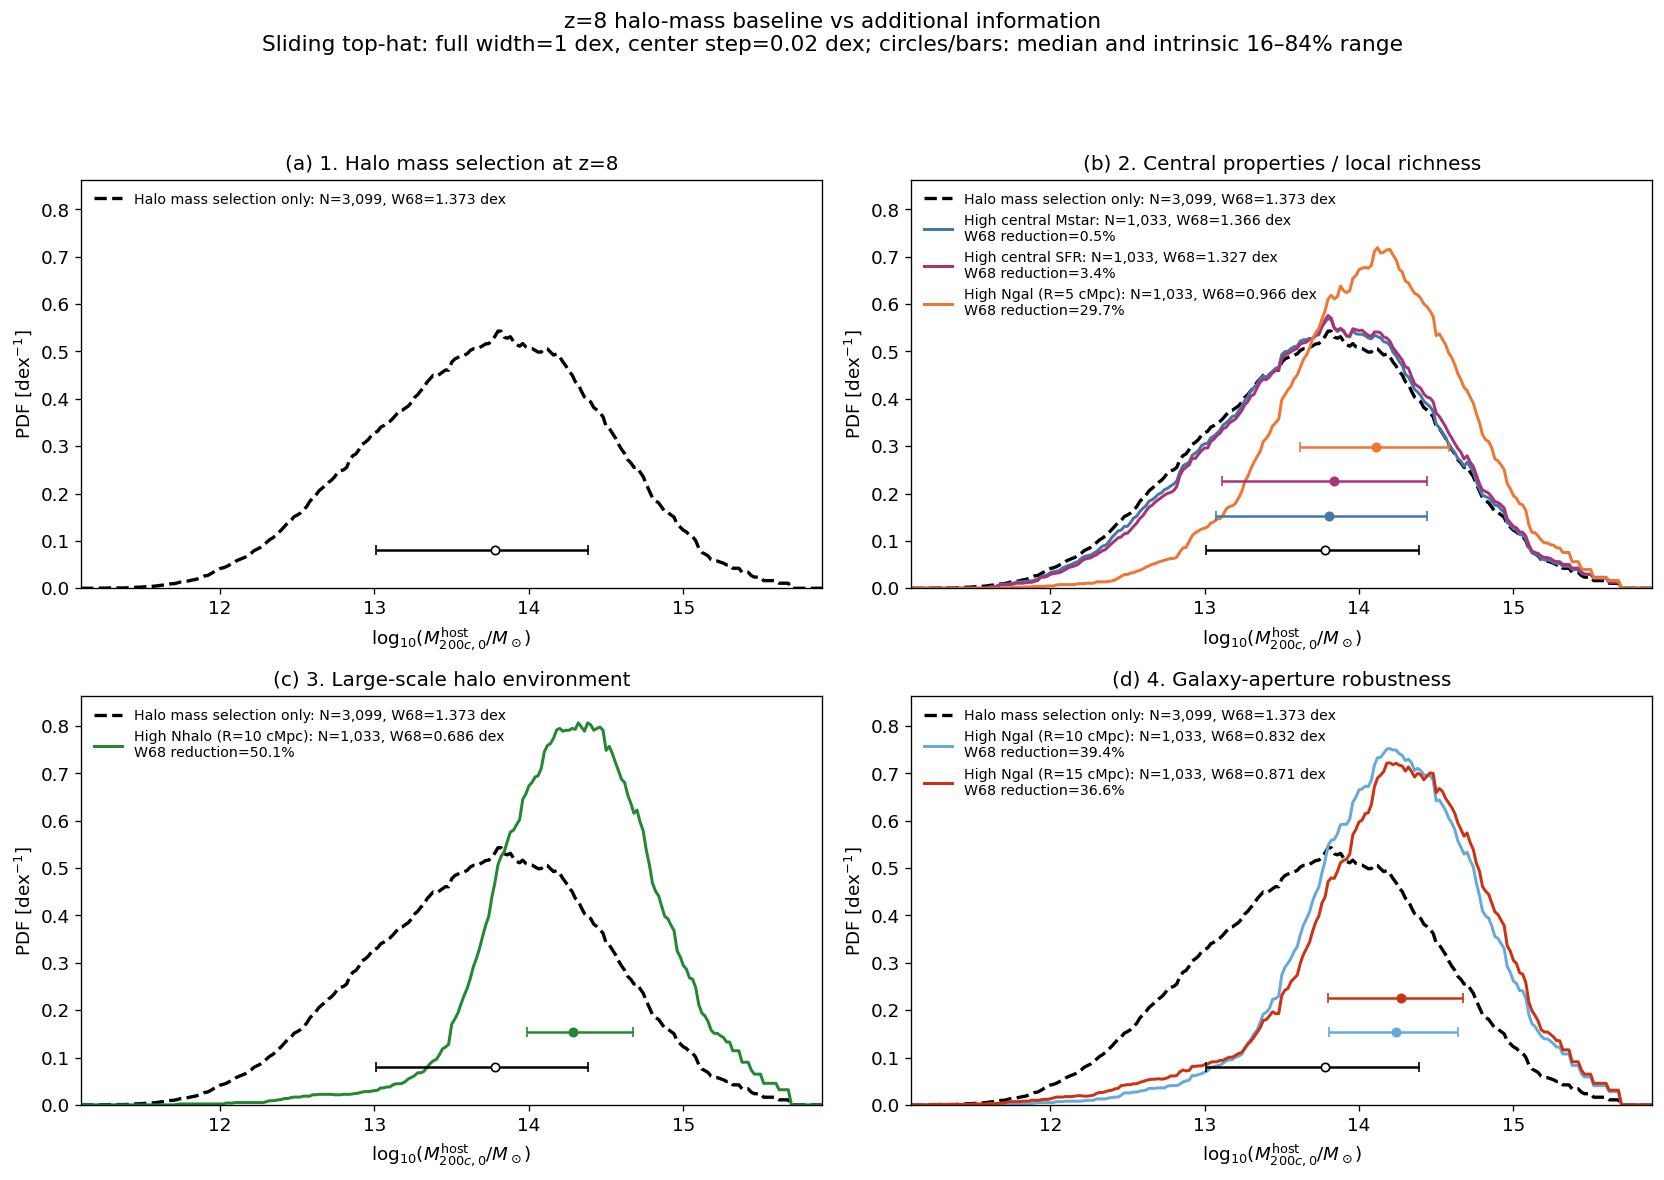

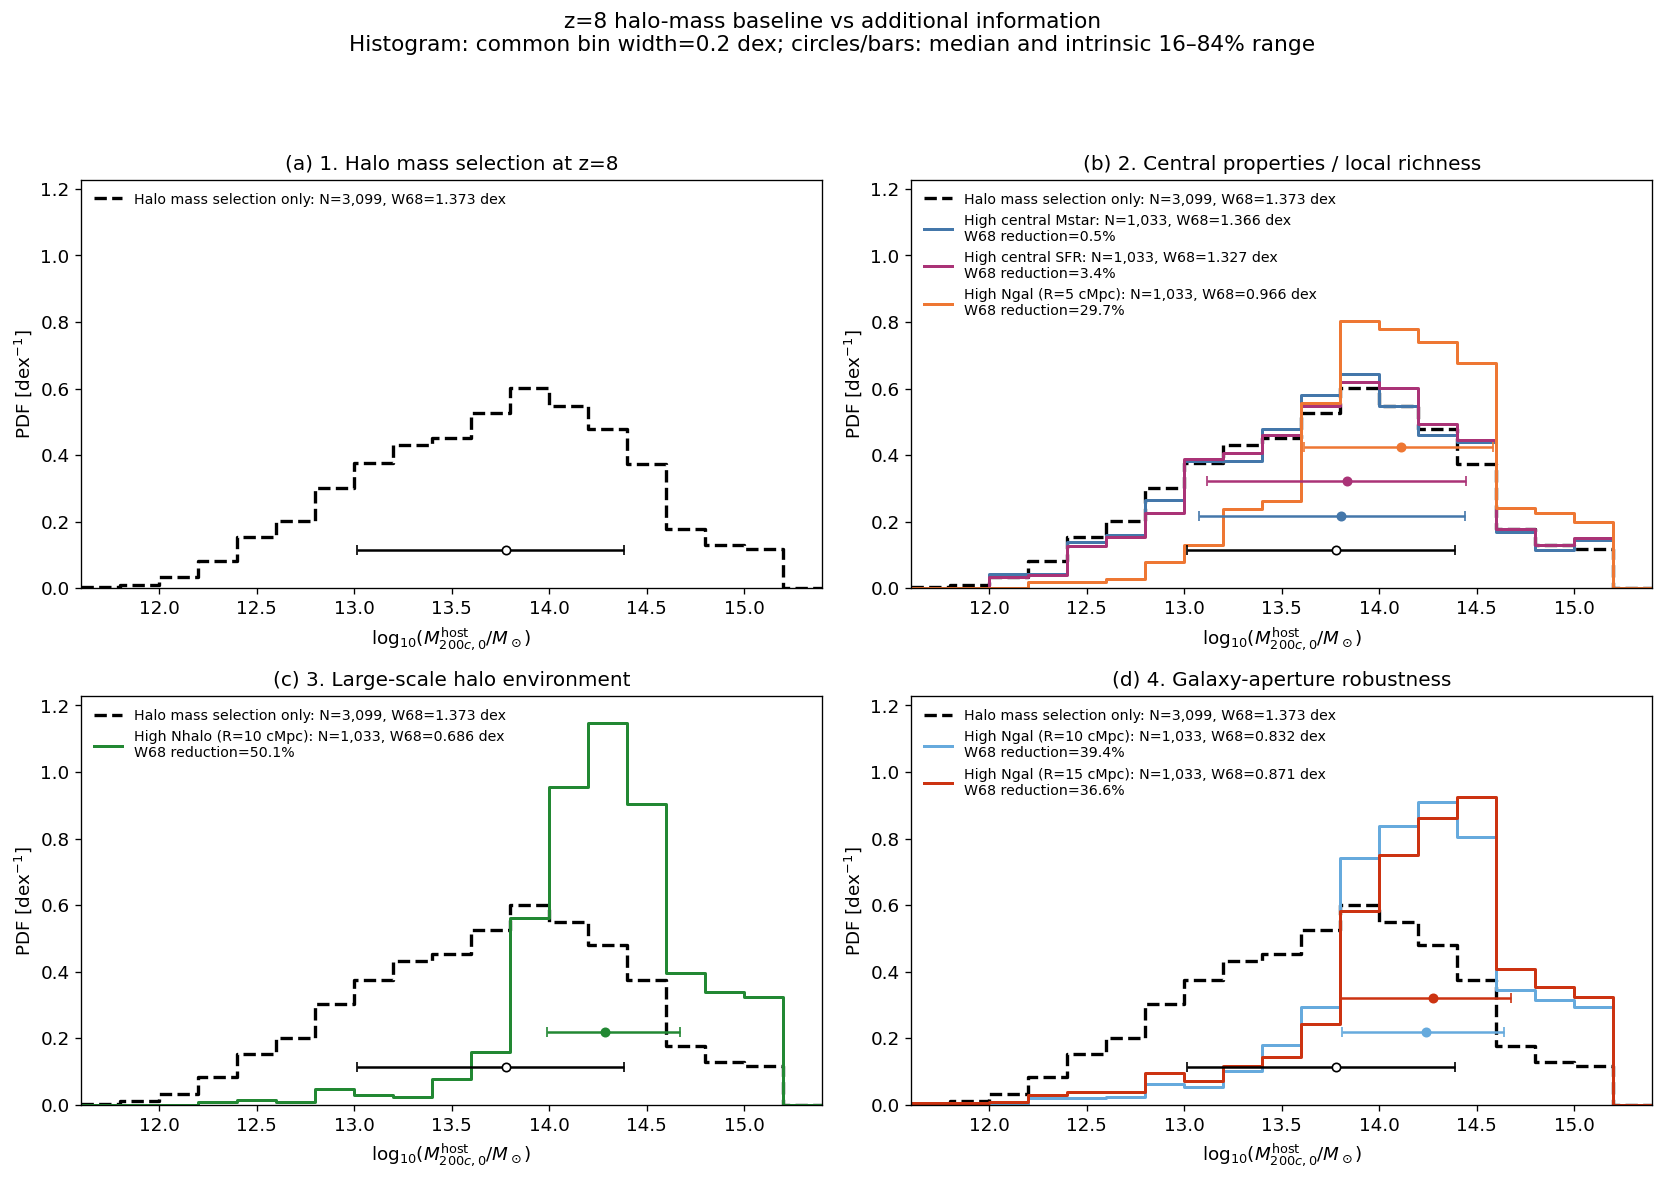

In [3]:
panels = [
    ('(a) 1. Halo mass selection at z=8', []),
    ('(b) 2. Central properties / local richness',
     ['high_mstar', 'high_sfr', 'high_ngal5']),
    ('(c) 3. Large-scale halo environment', ['high_nhalo10']),
    ('(d) 4. Galaxy-aperture robustness', ['high_ngal10', 'high_ngal15']),
]
colors = {'baseline': 'black', 'high_mstar': '#4477AA', 'high_sfr': '#AA3377',
          'high_ngal5': '#EE7733', 'high_nhalo10': '#228833',
          'high_ngal10': '#66AADD', 'high_ngal15': '#CC3311'}

def plot_pdf_comparison(mode='sliding'):
    if mode not in ['sliding', 'histogram']:
        raise ValueError(mode)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    all_keys = ['baseline', *features]
    tables = smooth_pdfs if mode == 'sliding' else raw_pdfs
    ymax = max(tables[key]['PDF_dex^-1'].max() for key in all_keys)
    for ax, (title, extra) in zip(axes.flat, panels):
        for j, key in enumerate(['baseline', *extra]):
            row = stats.loc[key]
            lab = f'{labels[key]}: N={int(row.N):,}, W68={row.W68_dex:.3f} dex'
            if key != 'baseline':
                lab += f'\nW68 reduction={row.W68_reduction_vs_baseline_pct:.1f}%'
            kwargs = dict(color=colors[key], ls='--' if key == 'baseline' else '-',
                          lw=2 if key == 'baseline' else 1.8, label=lab)
            if mode == 'sliding':
                ax.plot(tables[key].logM0, tables[key]['PDF_dex^-1'], **kwargs)
            else:
                draw_pdf(ax, tables[key]['PDF_dex^-1'], pdf_edges, **kwargs)
            # Bars show the intrinsic distribution range, not uncertainty on the median.
            y = ymax*(0.10+0.09*j)
            ax.errorbar(row['median'], y,
                        xerr=[[row['median']-row.p16], [row.p84-row['median']]],
                        fmt='o', color=colors[key],
                        mfc='white' if key == 'baseline' else colors[key],
                        capsize=3, ms=5, zorder=5)
        ax.set_title(title, fontsize=12)
        ax.set_ylim(0, ymax*1.07)
        ax.legend(fontsize=8.5, loc='upper left', frameon=False)
        ax.tick_params(labelbottom=True, labelleft=True)
    support = PDF_WINDOW_WIDTH_DEX/2 if mode == 'sliding' else 0
    axes[0, 0].set_xlim(pdf_edges[0]-support, pdf_edges[-1]+support)
    for ax in axes.flat:
        ax.set_xlabel(r'$\log_{10}(M_{200c,0}^{\rm host}/M_\odot)$')
        ax.set_ylabel(r'PDF [dex$^{-1}$]')
    detail = (f'Sliding top-hat: full width={PDF_WINDOW_WIDTH_DEX:g} dex, '
              f'center step={PDF_CENTER_STEP_DEX:g} dex' if mode == 'sliding'
              else f'Histogram: common bin width={PDF_BIN_WIDTH:g} dex')
    fig.suptitle('z=8 halo-mass baseline vs additional information\n'
                 +detail+'; circles/bars: median and intrinsic 16–84% range', fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    name = f'z8_pdf_information_{mode}'
    fig.savefig(fig_dir / f'{name}.png', dpi=180, bbox_inches='tight')
    fig.savefig(fig_dir / f'{name}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

plot_pdf_comparison('sliding')
plot_pdf_comparison('histogram')

### 図の読み方

- 黒破線は全パネルで同じ質量選択のみの基準。PDFはピークでなく**面積**を1に規格化している。
- 円と横バーは中央値と16–84%範囲。バーが短くなるほど元の分布が狭くなる。中央値の右移動だけでは「尖った」とは言わない。
- **尖り方の主指標は生の $W_{68}$ の縮小率**。ピーク比は共通の平滑化幅に依存する補助値であり、平滑化で得られた幅を統計値として使わない。
- 上位1/3という特定状況の結果で、全3群の幅の加重平均とは別の統計。条件を変えると分布や幅も変わる。
- 初期ハロー単位の重み付けを保つ。複数の初期ハローが同じ最終ホストへ入るので、独立した最終ホストのPDFとは異なる。
- (d)は頑健性解析の球環境を用いた半径比較。閾値変化・円柱の全結果を再現したものではない。探索済み半径・全標本の条件付き分布で、独立評価による性能推定ではない。

出力先：`../analysis_summary/z8_pdf_information/`。図は `figures/` にPNG・SVGで保存し、集計値・生ヒストグラム・平滑化PDF・選択対象ID・入力ファイルのハッシュも保存する。